In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

DB_PATH = "../db/fpl.db"
con = sqlite3.connect(DB_PATH)

print("Connected.")

Connected.


In [2]:
df = pd.read_sql("""
    SELECT
        pgs.player_id,
        pgs.gameweek_id,
        pgs.season,
        pgs.opponent_team,
        pgs.was_home,
        pgs.value,
        pgs.total_points,
        pgs.minutes,
        pgs.starts,
        pgs.goals_scored,
        pgs.assists,
        pgs.clean_sheets,
        pgs.goals_conceded,
        pgs.bonus,
        pgs.saves,
        pgs.expected_goals,
        pgs.expected_assists,
        pgs.expected_goal_involvements,
        pgs.expected_goals_conceded,
        pgs.influence,
        pgs.creativity,
        pgs.threat,
        pgs.transfers_in,
        pgs.transfers_out,
        pgs.selected,
        p.web_name,
        p.team_id,
        p.position_id,
        pos.singular_name_short   AS position
    FROM player_gameweek_stats pgs
    JOIN players p   ON pgs.player_id = p.id
    JOIN positions pos ON p.position_id = pos.id
    ORDER BY pgs.player_id, pgs.season, pgs.gameweek_id
""", con)

print(f"Loaded {len(df):,} rows")
print(df.shape)
df.head()

Loaded 104,383 rows
(104383, 29)


,player_id,gameweek_id,season,opponent_team,was_home,value,total_points,minutes,starts,goals_scored,...,influence,creativity,threat,transfers_in,transfers_out,selected,web_name,team_id,position_id,position
0,1,1,2022-23,Crystal Palace,0,45,0,0,0,0,...,0.0,0.0,0.0,0,0,23970,Raya,1,1,GKP
1,1,2,2022-23,Leicester,1,44,0,0,0,0,...,0.0,0.0,0.0,1361,6530,24193,Raya,1,1,GKP
2,1,3,2022-23,Bournemouth,0,44,0,0,0,0,...,0.0,0.0,0.0,879,5216,20960,Raya,1,1,GKP
3,1,4,2022-23,Fulham,1,43,0,0,0,0,...,0.0,0.0,0.0,577,3565,18825,Raya,1,1,GKP
4,1,5,2022-23,Aston Villa,1,43,0,0,0,0,...,0.0,0.0,0.0,405,2016,17790,Raya,1,1,GKP


Target variable

In [3]:
df['next_gw_points'] = (
    df.groupby(['player_id', 'season'])['total_points']
    .shift(-1)
)

# Drop the final gameweek of each season 
df = df.dropna(subset=['next_gw_points'])

print(f"Rows after dropping final GW per season: {len(df):,}")
print(f"\nTarget variable distribution:")
print(df['next_gw_points'].describe().round(2))


Rows after dropping final GW per season: 101,152

Target variable distribution:
count    101152.00
mean          1.16
std           2.36
min          -5.00
25%           0.00
50%           0.00
75%           1.00
max          26.00
Name: next_gw_points, dtype: float64


The median is 0 - this is an issue that wasn't accounted for in the previous model as of today. A large proportion of players are bench / filler players who do not get consistent minutes and the model should not be trained on them.

Instead we should only look at players who've played some sort of minutes over the last 3 weeks.

In [4]:
# Compute rolling minutes over last 3 gameweeks per player-season
df = df.sort_values(['player_id', 'season', 'gameweek_id'])

df['minutes_rolling_3'] = (
    df.groupby(['player_id', 'season'])['minutes']
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).sum())
)

# Compare thresholds
thresholds = [0, 45, 90, 135, 180]
print(f"{'Threshold':<20} {'Rows':>10} {'% of total':>12} {'Mean next pts':>15} {'Median next pts':>16}")
print("-" * 75)
for t in thresholds:
    subset = df[df['minutes_rolling_3'] > t]
    print(f"> {t} mins last 3 GWs  {len(subset):>10,} {len(subset)/len(df):>11.1%} {subset['next_gw_points'].mean():>15.2f} {subset['next_gw_points'].median():>16.1f}")

Threshold                  Rows   % of total   Mean next pts  Median next pts
---------------------------------------------------------------------------
> 0 mins last 3 GWs      49,418       48.9%            2.12              1.0
> 45 mins last 3 GWs      39,624       39.2%            2.40              1.0
> 90 mins last 3 GWs      32,400       32.0%            2.58              2.0
> 135 mins last 3 GWs      27,883       27.6%            2.71              2.0
> 180 mins last 3 GWs      20,963       20.7%            2.88              2.0


We decide to keep 90 minutes over 3 gameweeks as a trade off between. 

## New Features

In [5]:
df = df.sort_values(['player_id', 'season', 'gameweek_id'])

grp = df.groupby(['player_id', 'season'])

# --- Form variants ---
# shift(1) before rolling ensures we only look at gameweeks BEFORE the current one.
# Without shift(1), the current gameweek's value would be included — that's leakage.
df['form_3'] = grp['total_points'].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean()
)
df['form_5'] = grp['total_points'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)
df['form_10'] = grp['total_points'].transform(
    lambda x: x.shift(1).rolling(10, min_periods=1).mean()
)

# Form trend — positive means recent form better than medium-term form
df['form_trend'] = df['form_3'] - df['form_5']

# Points variance over last 5 — boom-or-bust measure
df['points_variance_5'] = grp['total_points'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=2).std()
)

# --- Availability features ---
df['minutes_rolling_3'] = grp['minutes'].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).sum()
)
df['minutes_rolling_5'] = grp['minutes'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).sum()
)
df['starts_rolling_5'] = grp['starts'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).sum()
)

# --- Bonus rate ---
df['bonus_rate_5'] = grp['bonus'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)

# --- Per-90 attacking stats (cumulative season) ---
df['cum_minutes'] = grp['minutes'].transform(lambda x: x.shift(1).cumsum())
df['cum_goals']   = grp['goals_scored'].transform(lambda x: x.shift(1).cumsum())
df['cum_assists']  = grp['assists'].transform(lambda x: x.shift(1).cumsum())
df['cum_xg']      = grp['expected_goals'].transform(lambda x: x.shift(1).cumsum())
df['cum_xa']      = grp['expected_assists'].transform(lambda x: x.shift(1).cumsum())

df['goals_per_90']   = (df['cum_goals']   / df['cum_minutes'] * 90).replace([np.inf, -np.inf], 0)
df['assists_per_90'] = (df['cum_assists'] / df['cum_minutes'] * 90).replace([np.inf, -np.inf], 0)
df['xg_per_90']      = (df['cum_xg']      / df['cum_minutes'] * 90).replace([np.inf, -np.inf], 0)
df['xa_per_90']      = (df['cum_xa']      / df['cum_minutes'] * 90).replace([np.inf, -np.inf], 0)

print("Player-level features computed.")
print(f"\nNaN counts in new features:")
new_features = [
    'form_3', 'form_5', 'form_10', 'form_trend', 'points_variance_5',
    'minutes_rolling_3', 'minutes_rolling_5', 'starts_rolling_5',
    'bonus_rate_5', 'goals_per_90', 'assists_per_90', 'xg_per_90', 'xa_per_90'
]
print(df[new_features].isna().sum())

Player-level features computed.

NaN counts in new features:
form_3                3222
form_5                3222
form_10               3222
form_trend            3222
points_variance_5     6432
minutes_rolling_3     3222
minutes_rolling_5     3222
starts_rolling_5      3222
bonus_rate_5          3222
goals_per_90         37760
assists_per_90       37760
xg_per_90            37760
xa_per_90            37760
dtype: int64


In [6]:
# --- ICT component rolling averages ---
# Using 5-gameweek rolling means for stability.
# ict_index is excluded — it's a weighted combination of the three components
# below, so including it alongside them would be redundant.

df['creativity_rolling_5'] = grp['creativity'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)
df['threat_rolling_5'] = grp['threat'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)
df['influence_rolling_5'] = grp['influence'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)

print("ICT rolling features computed.")
ict_features = ['creativity_rolling_5', 'threat_rolling_5', 'influence_rolling_5']
print(f"\nNaN counts:")
print(df[ict_features].isna().sum())

ICT rolling features computed.

NaN counts:
creativity_rolling_5    3222
threat_rolling_5        3222
influence_rolling_5     3222
dtype: int64


### Computing the defensive form

In [7]:
# --- Build team-gameweek summary directly from player_gameweek_stats ---
# Using the raw database table rather than the joined df means ALL teams
# appear — including historically relegated clubs like Leicester, Southampton
# etc. that don't exist in the current 2025-26 teams table.

raw_pgs = pd.read_sql("""
    SELECT 
        player_id,
        gameweek_id,
        season,
        opponent_team,
        goals_scored,
        goals_conceded,
        clean_sheets
    FROM player_gameweek_stats
    ORDER BY season, gameweek_id
""", con)

# Join team_id onto raw_pgs so we can group by team
players_ref = pd.read_sql("SELECT id, team_id FROM players", con)
raw_pgs = raw_pgs.merge(players_ref, left_on='player_id', right_on='id', how='left')

# One row per team per gameweek per season
# Every player on a team shares the same goals_conceded and clean_sheets
# value for a given gameweek — first() deduplicates cleanly
team_gw = (
    raw_pgs.groupby(['team_id', 'season', 'gameweek_id'])[['goals_conceded', 'clean_sheets']]
    .first()
    .reset_index()
    .sort_values(['team_id', 'season', 'gameweek_id'])
)

team_grp = team_gw.groupby(['team_id', 'season'])

team_gw['team_goals_conceded_rolling_5'] = team_grp['goals_conceded'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)
team_gw['team_clean_sheets_rolling_5'] = team_grp['clean_sheets'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)

# Join back onto main df
df = df.merge(
    team_gw[['team_id', 'season', 'gameweek_id',
              'team_goals_conceded_rolling_5',
              'team_clean_sheets_rolling_5']],
    on=['team_id', 'season', 'gameweek_id'],
    how='left'
)

print("Team defensive form features computed.")
print(f"\nNaN counts:")
print(df[['team_goals_conceded_rolling_5', 'team_clean_sheets_rolling_5']].isna().sum())

print(f"\nSalah team defensive form sample:")
print(
    df[df['web_name'] == 'M.Salah'][
        ['season', 'gameweek_id',
         'team_goals_conceded_rolling_5',
         'team_clean_sheets_rolling_5']
    ].head(10).to_string(index=False)
)

Team defensive form features computed.

NaN counts:
team_goals_conceded_rolling_5    2542
team_clean_sheets_rolling_5      2542
dtype: int64

Salah team defensive form sample:
 season  gameweek_id  team_goals_conceded_rolling_5  team_clean_sheets_rolling_5
2022-23            1                            NaN                          NaN
2022-23            2                            0.0                     1.000000
2022-23            3                            0.0                     1.000000
2022-23            4                            1.0                     0.666667
2022-23            5                            1.0                     0.500000
2022-23            6                            0.8                     0.400000
2022-23            8                            0.8                     0.400000
2022-23            9                            1.0                     0.200000
2022-23           10                            0.4                     0.400000
2022-23       

In [8]:
# --- Opponent difficulty features ---
# Built from raw_pgs grouped by opponent_team name directly.
# This works for ALL teams including relegated clubs because opponent_team
# is stored as a name string — no dependency on the teams table.

# Goals scored by each team per gameweek = sum of player goals scored
team_goals_scored = (
    raw_pgs.groupby(['opponent_team', 'season', 'gameweek_id'])['goals_scored']
    .sum()
    .reset_index()
    .rename(columns={'goals_scored': 'opp_goals_scored',
                     'opponent_team': 'opp_name'})
    .sort_values(['opp_name', 'season', 'gameweek_id'])
)

# Goals conceded and clean sheets by opponent
# Use first() to deduplicate — all players facing the same opponent
# share the same goals_conceded value for that gameweek
opp_defensive = (
    raw_pgs.groupby(['opponent_team', 'season', 'gameweek_id'])[['goals_conceded', 'clean_sheets']]
    .first()
    .reset_index()
    .rename(columns={'opponent_team': 'opp_name',
                     'goals_conceded': 'opp_goals_conceded',
                     'clean_sheets': 'opp_clean_sheets'})
    .sort_values(['opp_name', 'season', 'gameweek_id'])
)

opp_gw = team_goals_scored.merge(
    opp_defensive,
    on=['opp_name', 'season', 'gameweek_id'],
    how='outer'
)

opp_grp = opp_gw.groupby(['opp_name', 'season'])

opp_gw['opponent_goals_scored_rolling_5'] = opp_grp['opp_goals_scored'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)
opp_gw['opponent_goals_conceded_rolling_5'] = opp_grp['opp_goals_conceded'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)
opp_gw['opponent_clean_sheets_rolling_5'] = opp_grp['opp_clean_sheets'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)

# Join opponent features back onto main df
df = df.merge(
    opp_gw[['opp_name', 'season', 'gameweek_id',
             'opponent_goals_scored_rolling_5',
             'opponent_goals_conceded_rolling_5',
             'opponent_clean_sheets_rolling_5']].rename(columns={'opp_name': 'opponent_team'}),
    on=['opponent_team', 'season', 'gameweek_id'],
    how='left'
)

print("Opponent difficulty features computed.")
opp_features = [
    'opponent_goals_scored_rolling_5',
    'opponent_goals_conceded_rolling_5',
    'opponent_clean_sheets_rolling_5'
]
print(f"\nNaN counts:")
print(df[opp_features].isna().sum())

print(f"\nSalah opponent difficulty sample:")
print(
    df[df['web_name'] == 'M.Salah'][
        ['season', 'gameweek_id', 'opponent_team',
         'opponent_goals_conceded_rolling_5',
         'opponent_clean_sheets_rolling_5']
    ].head(10).to_string(index=False)
)

Opponent difficulty features computed.

NaN counts:
opponent_goals_scored_rolling_5      2537
opponent_goals_conceded_rolling_5    2537
opponent_clean_sheets_rolling_5      2537
dtype: int64

Salah opponent difficulty sample:
 season  gameweek_id opponent_team  opponent_goals_conceded_rolling_5  opponent_clean_sheets_rolling_5
2022-23            1     Newcastle                                NaN                              NaN
2022-23            2      West Ham                           0.000000                              0.0
2022-23            3       Everton                           0.500000                              0.0
2022-23            4         Spurs                           0.333333                              0.0
2022-23            5      Man City                           2.250000                              0.0
2022-23            6   Bournemouth                           0.400000                              0.2
2022-23            8        Fulham                   

Here we apply the 90 minute filter

In [11]:
# --- Apply 90-minute filter ---
# Keep only rows where the player accumulated at least 90 minutes
# across the prior 3 gameweeks. Applied AFTER all rolling features
# are computed so each player's history remains unbroken.

df_model = df[df['minutes_rolling_3'] >= 90].copy()

print(f"Rows before filter: {len(df):,}")
print(f"Rows after 90-min filter: {len(df_model):,}")
print(f"Rows removed: {len(df) - len(df_model):,} ({(1 - len(df_model)/len(df)):.1%})")

# --- Define feature columns ---
FEATURE_COLS = [
    # Form
    'form_3', 'form_5', 'form_10', 'form_trend', 'points_variance_5',
    # Availability
    'minutes_rolling_3', 'minutes_rolling_5', 'starts_rolling_5',
    # Output quality
    'bonus_rate_5',
    'goals_per_90', 'assists_per_90', 'xg_per_90', 'xa_per_90',
    # ICT components
    'creativity_rolling_5', 'threat_rolling_5', 'influence_rolling_5',
    # Own team defensive form
    'team_goals_conceded_rolling_5', 'team_clean_sheets_rolling_5',
    # Opponent difficulty
    'opponent_goals_scored_rolling_5',
    'opponent_goals_conceded_rolling_5',
    'opponent_clean_sheets_rolling_5',
    # Context
    'was_home', 'value'
]

# --- Fill NaNs ---
# Remaining NaNs after the 90-min filter are early-season rows where
# rolling history doesn't exist yet. Filled with 0 — a player with
# no prior history genuinely has 0 contribution on these measures.
df_model[FEATURE_COLS] = df_model[FEATURE_COLS].fillna(0)

print(f"\nFeature matrix shape: {df_model[FEATURE_COLS].shape}")
print(f"\nRemaining NaNs after fillna:")
print(df_model[FEATURE_COLS].isna().sum())
print(f"\nTarget variable distribution after filter:")
print(df_model['next_gw_points'].describe().round(2))
print(f"\nRows by season after filter:")
print(df_model.groupby('season').size())

Rows before filter: 101,152
Rows after 90-min filter: 34,726
Rows removed: 66,426 (65.7%)

Feature matrix shape: (34726, 23)

Remaining NaNs after fillna:
form_3                               0
form_5                               0
form_10                              0
form_trend                           0
points_variance_5                    0
minutes_rolling_3                    0
minutes_rolling_5                    0
starts_rolling_5                     0
bonus_rate_5                         0
goals_per_90                         0
assists_per_90                       0
xg_per_90                            0
xa_per_90                            0
creativity_rolling_5                 0
threat_rolling_5                     0
influence_rolling_5                  0
team_goals_conceded_rolling_5        0
team_clean_sheets_rolling_5          0
opponent_goals_scored_rolling_5      0
opponent_goals_conceded_rolling_5    0
opponent_clean_sheets_rolling_5      0
was_home                  

In [12]:
print(df_model[['opponent_goals_scored_rolling_5',
                 'opponent_goals_conceded_rolling_5', 
                 'opponent_clean_sheets_rolling_5']].isna().sum())

print(f"\nTarget variable distribution after filter:")
print(df_model['next_gw_points'].describe().round(2))

opponent_goals_scored_rolling_5      0
opponent_goals_conceded_rolling_5    0
opponent_clean_sheets_rolling_5      0
dtype: int64

Target variable distribution after filter:
count    34726.00
mean         2.52
std          3.05
min         -4.00
25%          1.00
50%          2.00
75%          3.00
max         26.00
Name: next_gw_points, dtype: float64


## Correlation Matrix

Feature correlations with next_gw_points:
form_10                              0.233
form_5                               0.210
value                                0.208
form_3                               0.194
threat_rolling_5                     0.180
influence_rolling_5                  0.176
minutes_rolling_3                    0.161
creativity_rolling_5                 0.155
bonus_rate_5                         0.150
minutes_rolling_5                    0.142
goals_per_90                         0.140
xg_per_90                            0.122
points_variance_5                    0.120
assists_per_90                       0.097
xa_per_90                            0.090
starts_rolling_5                     0.086
team_clean_sheets_rolling_5          0.029
opponent_goals_conceded_rolling_5    0.025
form_trend                           0.021
opponent_clean_sheets_rolling_5      0.016
opponent_goals_scored_rolling_5     -0.001
team_goals_conceded_rolling_5       -0.005
was_home    

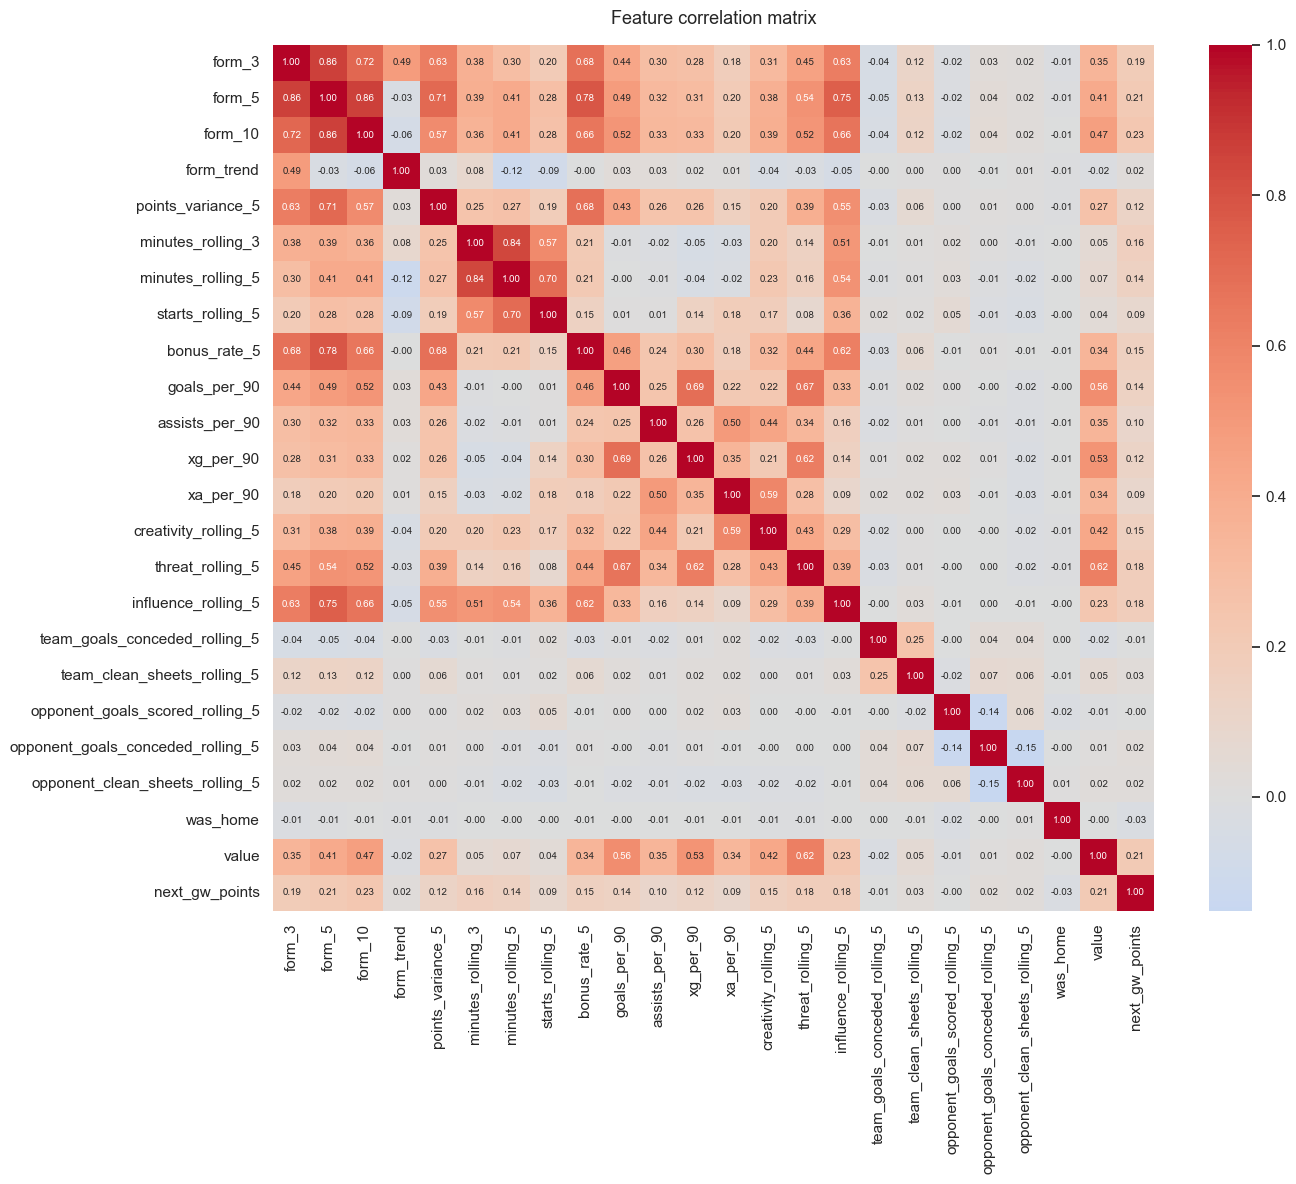

In [13]:
# --- Correlation matrix ---
# Pearson correlation between every feature and the target variable.
# Values close to 1 or -1 = strong linear relationship.
# Values close to 0 = weak linear relationship.

corr_cols = FEATURE_COLS + ['next_gw_points']
corr_matrix = df_model[corr_cols].corr()

# --- Correlation with target specifically ---
target_corr = (
    corr_matrix['next_gw_points']
    .drop('next_gw_points')
    .sort_values(ascending=False)
)

print("Feature correlations with next_gw_points:")
print(target_corr.round(3).to_string())

# --- Heatmap of full correlation matrix ---
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    ax=ax,
    annot_kws={'size': 7}
)
ax.set_title('Feature correlation matrix', fontsize=13, pad=15)
plt.tight_layout()
plt.show()

Checking by positions

In [14]:
# Check correlation of team/opponent features with next_gw_points
# split by position — the signal may be position-specific
position_features = [
    'team_clean_sheets_rolling_5',
    'team_goals_conceded_rolling_5', 
    'opponent_goals_conceded_rolling_5',
    'opponent_goals_scored_rolling_5',
    'next_gw_points'
]

for pos in ['GKP', 'DEF', 'MID', 'FWD']:
    subset = df_model[df_model['position'] == pos]
    corr = subset[position_features].corr()['next_gw_points'].drop('next_gw_points')
    print(f"\n{pos} (n={len(subset):,}):")
    print(corr.round(3).to_string())


GKP (n=3,849):
team_clean_sheets_rolling_5          0.032
team_goals_conceded_rolling_5       -0.010
opponent_goals_conceded_rolling_5    0.033
opponent_goals_scored_rolling_5     -0.001

DEF (n=12,125):
team_clean_sheets_rolling_5          0.044
team_goals_conceded_rolling_5        0.000
opponent_goals_conceded_rolling_5    0.031
opponent_goals_scored_rolling_5     -0.001

MID (n=15,308):
team_clean_sheets_rolling_5          0.022
team_goals_conceded_rolling_5       -0.013
opponent_goals_conceded_rolling_5    0.019
opponent_goals_scored_rolling_5      0.007

FWD (n=3,444):
team_clean_sheets_rolling_5          0.000
team_goals_conceded_rolling_5        0.014
opponent_goals_conceded_rolling_5    0.018
opponent_goals_scored_rolling_5     -0.030


In [16]:
defs = df_model[df_model['position'] == 'DEF'].copy()

print("DEF team_clean_sheets_rolling_5 distribution:")
print(defs['team_clean_sheets_rolling_5'].describe().round(3))
print(f"Proportion that are exactly 0: {(defs['team_clean_sheets_rolling_5'] == 0).mean():.1%}")

defs['cs_rate_bin'] = pd.qcut(
    defs['team_clean_sheets_rolling_5'],
    q=4,
    labels=False,
    duplicates='drop'
)

print("\nDefender next_gw_points by team clean sheet rate bin:")
print(
    defs.groupby('cs_rate_bin')['next_gw_points']
    .agg(['mean', 'median', 'count'])
    .round(3)
)

gks = df_model[df_model['position'] == 'GKP'].copy()
gks['cs_rate_bin'] = pd.qcut(
    gks['team_clean_sheets_rolling_5'],
    q=4,
    labels=False,
    duplicates='drop'
)

print("\nGoalkeeper next_gw_points by team clean sheet rate bin:")
print(
    gks.groupby('cs_rate_bin')['next_gw_points']
    .agg(['mean', 'median', 'count'])
    .round(3)
)

DEF team_clean_sheets_rolling_5 distribution:
count    12125.000
mean         0.080
std          0.167
min          0.000
25%          0.000
50%          0.000
75%          0.000
max          1.000
Name: team_clean_sheets_rolling_5, dtype: float64
Proportion that are exactly 0: 76.1%

Defender next_gw_points by team clean sheet rate bin:
              mean  median  count
cs_rate_bin                      
0            2.474     1.0  12125

Goalkeeper next_gw_points by team clean sheet rate bin:
              mean  median  count
cs_rate_bin                      
0            2.489     2.0   3849


In [17]:
# Compare static team strength ratings vs rolling clean sheet rate
# for defenders — does the static rating have more signal?
teams_strength = pd.read_sql("""
    SELECT id, name, strength_defence_home, strength_defence_away
    FROM teams
""", con)

defs2 = df_model[df_model['position'] == 'DEF'].copy()
defs2 = defs2.merge(
    teams_strength, 
    left_on='team_id', 
    right_on='id', 
    how='left'
)

print("Correlation of strength ratings with defender next_gw_points:")
print(defs2[['strength_defence_home', 'strength_defence_away', 
              'next_gw_points']].corr()['next_gw_points'].round(3))

print("\nDefender next_gw_points by strength_defence_home quartile:")
defs2['strength_bin'] = pd.qcut(
    defs2['strength_defence_home'], 
    q=4, 
    labels=['Q1 (weakest)', 'Q2', 'Q3', 'Q4 (strongest)'],
    duplicates='drop'
)
print(
    defs2.groupby('strength_bin')['next_gw_points']
    .agg(['mean', 'median', 'count'])
    .round(3)
)

Correlation of strength ratings with defender next_gw_points:
strength_defence_home    0.064
strength_defence_away    0.078
next_gw_points           1.000
Name: next_gw_points, dtype: float64

Defender next_gw_points by strength_defence_home quartile:
                 mean  median  count
strength_bin                        
Q1 (weakest)    2.274     1.0   3774
Q2              2.499     2.0   2579
Q3              2.585     2.0   4402
Q4 (strongest)  2.621     2.0   1370


## Feature Analysis: Team and Opponent Difficulty Features

Rolling team defensive features (goals conceded, clean sheets over 5 gameweeks) 
show close to zero correlation with next_gw_points even when we split by position. 
Looking at the distribution: 76% of defender rows have a rolling clean 
sheet rate of exactly 0.0. There just isn't enough variance for the model.

Static team strength ratings are slightly better (r=0.064–0.078 for 
defenders) with a meaningful increase from weakest to strongest defensive teams 
(2.27 vs 2.62 average next_gw_points). However correlations remain low across 
all positions.

We'll keep them for now for the Random Forest feature importance.

In [18]:
# --- Save feature matrix ---

SAVE_COLS = [
    'player_id', 'gameweek_id', 'season', 'position', 'web_name'
] + FEATURE_COLS + ['next_gw_points']

save_path = '../data/feature_matrix.csv'
df_model[SAVE_COLS].to_csv(save_path, index=False)

print(f"Feature matrix saved to {save_path}")
print(f"Shape: {df_model[SAVE_COLS].shape}")
print(f"\nColumns saved:")
print(df_model[SAVE_COLS].columns.tolist())

Feature matrix saved to ../data/feature_matrix.csv
Shape: (34726, 29)

Columns saved:
['player_id', 'gameweek_id', 'season', 'position', 'web_name', 'form_3', 'form_5', 'form_10', 'form_trend', 'points_variance_5', 'minutes_rolling_3', 'minutes_rolling_5', 'starts_rolling_5', 'bonus_rate_5', 'goals_per_90', 'assists_per_90', 'xg_per_90', 'xa_per_90', 'creativity_rolling_5', 'threat_rolling_5', 'influence_rolling_5', 'team_goals_conceded_rolling_5', 'team_clean_sheets_rolling_5', 'opponent_goals_scored_rolling_5', 'opponent_goals_conceded_rolling_5', 'opponent_clean_sheets_rolling_5', 'was_home', 'value', 'next_gw_points']
